/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats
t2tv2
PAR1      1
XDR1      0
XTR1      0
AMPL1     0
XTR2      0
XDR2      0
AMPL2     0
SAT       0
CEN      18
DYZ17     0
XDR3      0
AMPL3     0
XDR4      0
AMPL4     0
XDR5      0
AMPL5     0
XDR6      0
AMPL6     0
XDR7      0
DYZ19     1
XDR8      1
AMPL7    12
OTHER     0
HET       4
PAR2      0
dtype: int64
hg38
PAR1           1.0
XDR1           0.0
XTR1           0.0
AMPL1_IR3d     1.0
XTR2           0.0
XDR2           0.0
AMPL2          1.0
other1         0.0
CEN           18.0
CEN_DYZ3       6.0
XDR3           0.0
AMPL3          0.0
XDR4           0.0
AMPL4          0.0
XDR5           0.0
AMPL5          0.0
XDR6           0.0
AMPL6          0.0
XDR7           0.0
DYZ19          1.0
XDR8           1.0
AMPL7         13.0
other2         0.0
HET           16.0
PAR2           0.0
dtype: float64


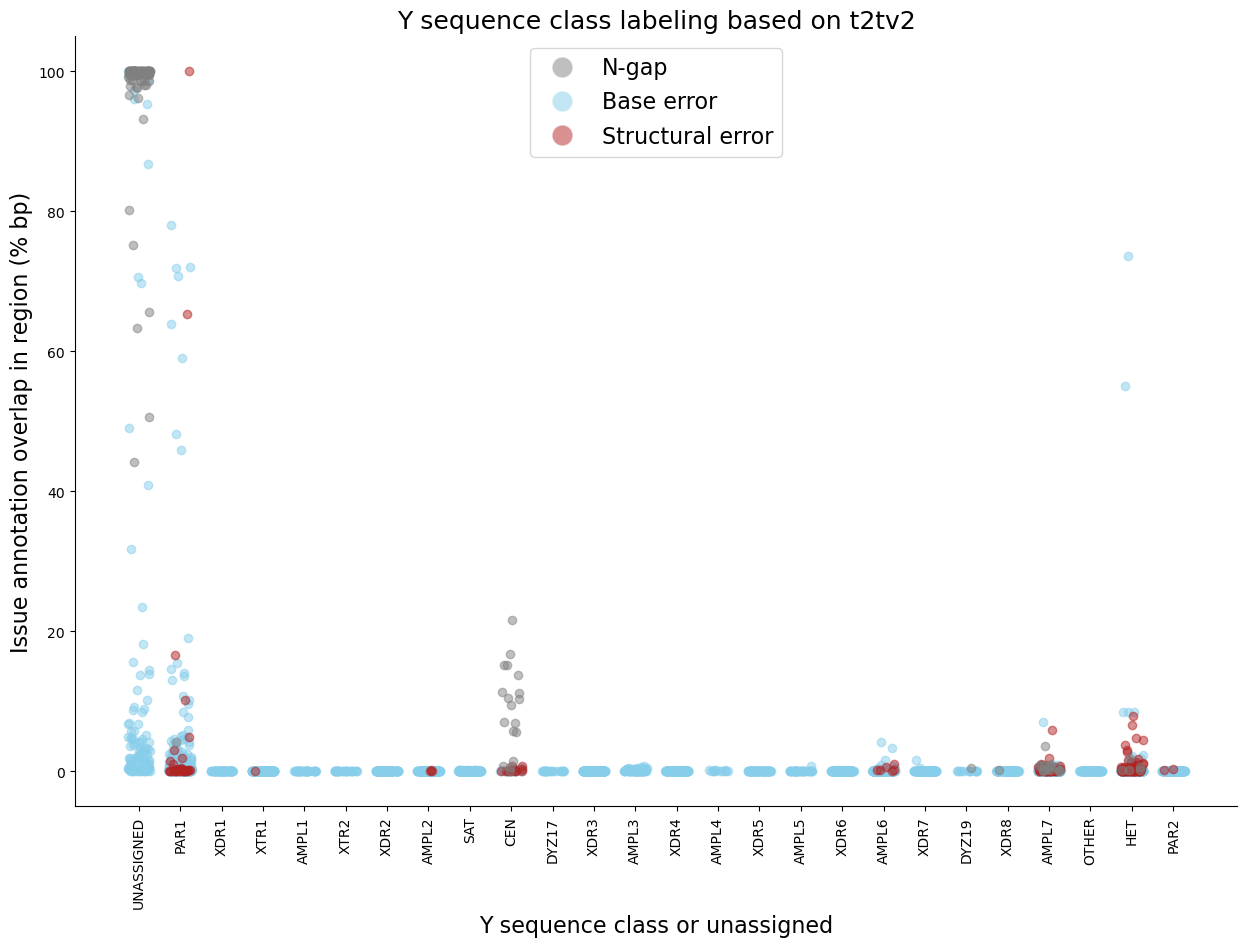

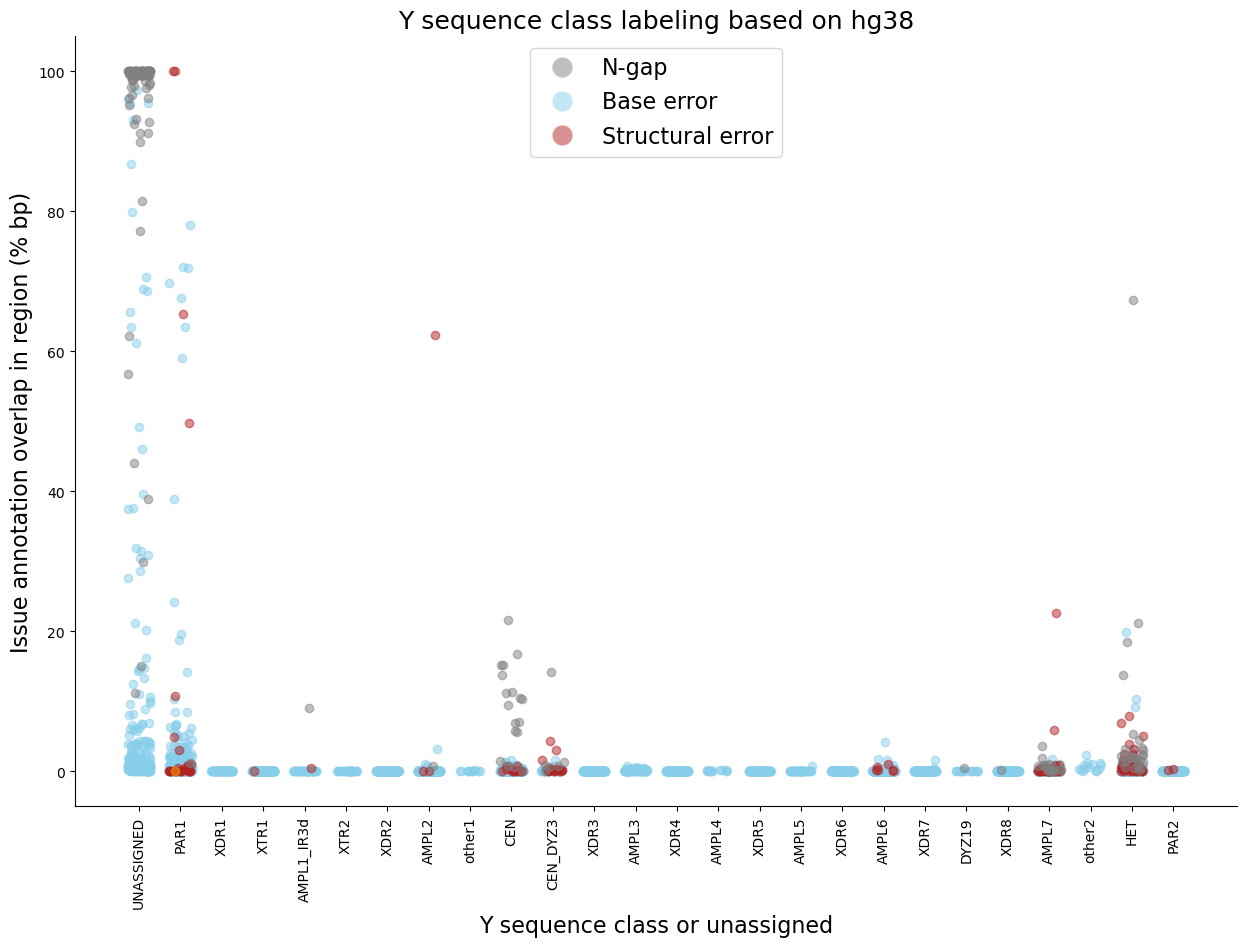

In [96]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

print(DATA_ROOT)
print(PLOT_ROOT)

# actual NB code

import collections as col
import dataclasses as dcl
import pandas as pd
import re
import itertools as itt
import numpy.random as rng
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mplcol
import matplotlib.lines as mpllin

ref_base_path = pl.Path("/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/norm")

ref_files = {
    "t2tv2": "HG002-Y_T2Tv2_regions_repeat-details.bed",
    "hg38": "GRCh38-Y_regions_repeat-details.bed"
}
ref_hg = {
    "t2tv2": "J1",
    "hg38": "R1"
}

@dcl.dataclass
class IssueColors:
    NGAP = mplcol.to_rgba("grey", alpha=0.5)
    ERRSTRUCT = mplcol.to_rgba("firebrick", alpha=0.5)
    ERRBASE = mplcol.to_rgba("skyblue", alpha=0.5)
    UNASSIGNED = mplcol.to_rgba("orange", alpha=0.5)
    
    def get_color_labels(self):
        labels = [
            "unassigned",
            "N-gap",
            "Base error",
            "Structural error",
        ]
        return labels

    def get_issue_labels(self):
        labels = [
            "UNASSIGNED",
            "NGAP",
            "ERRBASE",
            "ERRSTRUCT"
        ]
        return labels


issue_colors = IssueColors()

data_folder = DATA_ROOT.joinpath("wf-data", "region-labels", "label_stats")

def is_umbrella(region):
    return re.match("[0-9]+[un]+_", region) is not None


def adjust_ref_label(label):

    if label == "CEN2":
        return None
    if label == "CEN1":
        return "CEN"
    return label


def compute_indicator_table(data_table, ref_labels):

    agg = data_table.groupby(["sample", "name", "name2"]).size()
    assert ref_labels[0] == "UNASSIGNED"

    samples = sorted(set(agg.index.get_level_values("sample")))
    num_samples = len(samples)
    num_issues = len(issue_colors.get_color_labels()) - 1  # ignore unassigned
    issue_labels = issue_colors.get_issue_labels()[1:]
    indicator = pd.DataFrame(
        np.zeros((num_samples*num_issues, len(ref_labels) - 1), dtype=int),
        columns=ref_labels[1:],
        index=pd.MultiIndex.from_tuples(
            [(s, i) for s, i in itt.product(samples, issue_labels)],
            names=["sample", "issue"]
        )
    )
    
    for (sample, region, issue), _ in agg.items():
        if region == "UNASSIGNED":
            continue
        indicator.loc[(sample, issue), region] = 1

    gaps_only = indicator.xs("NGAP", level="issue")
    print(gaps_only.sum(axis=0))
        


for ref, ref_file in ref_files.items():
    print(ref)
    
    ref_fp = ref_base_path.joinpath(ref_file)
    ref_regions = pd.read_csv(ref_fp, sep="\t", header=0)
    ref_regions["umbrella"] = ref_regions["name"].apply(is_umbrella)
    ref_labels = ref_regions.loc[ref_regions["umbrella"], "seqclass"].values
    ref_labels = ["UNASSIGNED"] + list(ref_labels)
    ref_labels = [adjust_ref_label(label) for label in ref_labels if adjust_ref_label(label) is not None]
    
    # because of the label-based selection below, we can't distinguish
    # the order and remove duplicates here
    tmp = []
    for l in ref_labels:
        if l in tmp:
            continue
        tmp.append(l)
    ref_labels = tmp
    tmp = []

    issue_labels = issue_colors.get_issue_labels()

    data_table_file = data_folder.joinpath(f"{ref}.final-draft-ovl-stats.tsv")
    data_table = pd.read_csv(data_table_file, sep="\t", header=0)
    
    # fix the usual naming issues...
    # relevant for both references
    renamer_sample_to_ref = {
        "DYZ19_Yq": "DYZ19",
        "CEN-DYZ3": "CEN_DYZ3",
        "periCEN": "CEN"
    }

    # consider only main seqs
    data_table = data_table.loc[data_table["seq_type"] == "main", :].copy()
    # rename for proper name matching
    data_table["name"] = data_table["name"].replace(renamer_sample_to_ref)
    # drop id/self ovl.
    data_table = data_table.loc[data_table["name"] != data_table["name2"], :].copy()
    data_table = data_table.loc[data_table["name"].isin(ref_labels), :].copy()
    # only check issue categories
    data_table = data_table.loc[data_table["name2"].isin(issue_labels), :].copy()

    _ = compute_indicator_table(data_table, ref_labels)
    
    plot_data = data_table.groupby(["name", "name2"])["overlap_pct"].apply(list)

    fig, ax = plt.subplots(figsize=(15,10))
    x_labels = []
    for idx_pos, label in enumerate(ref_labels, start=0):
        x_labels.append(label)
        try:
            sub = plot_data.xs(label, level="name")
        except KeyError:
            continue

        for other, y_values in sub.items():
            color = getattr(issue_colors, other)
            x_values = rng.uniform(idx_pos-0.275, idx_pos+0.275, size=len(y_values))
            ax.scatter(x_values, y_values, color=color)

    x_ticks = np.arange(0, len(ref_labels))
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Y sequence class or unassigned", fontsize=16)
    ax.set_ylabel("Issue annotation overlap in region (% bp)", fontsize=16)

    legend_elements = []
    
    for other, legend_label in zip(issue_labels, issue_colors.get_color_labels()):
        if other == "UNASSIGNED":
            continue
        color = getattr(issue_colors, other)
        elem = mpllin.Line2D(
            [], [], color="white",
            markerfacecolor=color, markersize=15,
            marker="o", label=legend_label
        )
        legend_elements.append(elem)
    ax.legend(handles=legend_elements, loc='upper center', fontsize=16)
    ax.set_title(f"Y sequence class labeling based on {ref}", fontsize=18)

    out_path = PLOT_ROOT.joinpath(f"issue-region-overlap.{ref}.png")
    out_path.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    

    
    

    